# **Demo Músicas**

Fonte: [Introdução ao Processamento de Linguagem Natural com Baco Exu do Blues](https://medium.com/turing-talks/introdu%C3%A7%C3%A3o-ao-processamento-de-linguagem-natural-com-baco-exu-do-blues-17cbb7404258)

## Importando bibliotecas

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import nltk
import matplotlib.pyplot as plt
import re
import spacy

## Fazendo o Web Scraping das músicas

O exemplo original utiliza o material do rapper brasileiro Exú do Blues, mas como sou mais da antiga, vou utilizar o material da banda de rock mais famosa da minha adolescência, Legião Urbana.

In [ ]:
page = requests.get("https://www.vagalume.com.br/legiao-urbana/")
soup = BeautifulSoup(page.content, 'html.parser')
lista_alfabetica = BeautifulSoup(str(soup.find_all(id = "alfabetMusicList")), 'html.parser')
a_tag = lista_alfabetica.find_all('a')

musicas = []
for a in a_tag:
    nome_musica = a.text
    if not(nome_musica == 'TRADUÇÃO' or nome_musica == ''):
        link_musica = a['href']
        musicas.append([nome_musica, link_musica])

for i in range(len(musicas)):
    link = "https://www.vagalume.com.br" + str(musicas[i][1])
    page = requests.get(link)
    soup = BeautifulSoup(page.content, 'html.parser')
    h3_tag = soup.find_all('h3')
    if len(h3_tag) != 0:
        album = h3_tag[0].text
    else:
        album = ''
    lyrics = soup.find_all(id = 'lyrics')
    lyrics = str(lyrics[0])
    lyrics = lyrics.replace('<div id="lyrics">', '')
    lyrics = lyrics.replace('<div data-plugin="googleTranslate" id="lyrics">', '')
    lyrics = lyrics.replace('<br/>', ' ')
    lyrics = lyrics.replace("\'","'")
    lyrics = lyrics.replace('</div>', '')
    musicas[i].append(album)
    musicas[i].append(lyrics)

musicas = pd.DataFrame(musicas, columns=['Nome da Música', 'link', 'album', 'letra'])

In [ ]:
musicas

,Nome da Música,link,album,letra
0,1965 (Duas Tribos),/legiao-urbana/1965-duas-tribos.html,As Quatro Estações: ao Vivo,Vou passar Quero ver Volta aqui Vem você Como ...
1,1977,/legiao-urbana/1977.html,,Todos os dias quando acordo de manhã Não tenho...
2,1º de julho,/legiao-urbana/1-de-julho.html,A Tempestade ou o Livro dos Dias,Eu vejo que aprendi O quanto te ensinei E nos ...
3,A Canção do Senhor da Guerra,/legiao-urbana/a-cancao-do-senhor-da-guerra.html,Música para Acampamentos,Existe alguém esperando por você Que vai compr...
4,A Dança,/legiao-urbana/a-danca.html,Legião Urbana - 30 Anos,Não sei o que é direito Só vejo preconceito E ...
...,...,...,...,...
112,Um Dia Perfeito,/legiao-urbana/um-dia-perfeito.html,Como é que se Diz Eu Te Amo,Quase morri Há menos de trinta e duas horas at...
113,Uma Outra Estação,/legiao-urbana/uma-outra-estacao.html,Uma Outra Estação,Sei que não tenho a força que tens Se me vejo...
114,Vamos Fazer um Filme,/legiao-urbana/vamos-fazer-um-filme.html,Como é que se Diz Eu Te Amo,Achei um 3x4 teu e não quis acreditar Que tinh...
115,Vento No Litoral,/legiao-urbana/vento-no-litoral.html,Como é que se Diz Eu Te Amo,De tarde quero descansar Chegar até a praia e ...


## Carregando a infraestrutura relacionada ao português da biblioteca Spacy.

In [ ]:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 61.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
spc_pt = spacy.load('pt_core_news_sm')

## Carregando a infraestrutura do português da biblioteca NLTK

In [ ]:
#nltk.download('stopwords')

## Limpeza do texto

Criando uma lista de stopwords mais completa, a partir do site [Lista super-hiper-mega-blaster-ultra completa das Stop Words em Português](https://blog.trifenol.com/lista-completa-das-stop-words-em-portugues/)

In [ ]:
stopwords_br = [
    # Artigos e contrações
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas', 'ao', 'à', 'aos', 'às',
    'do', 'da', 'dos', 'das', 'no', 'na', 'nos', 'nas', 'pelo', 'pela', 'pelos', 'pelas',

    # Pronomes
    'eu', 'tu', 'ele', 'ela', 'nós', 'vós', 'eles', 'elas', 'me', 'mim', 'comigo',
    'te', 'ti', 'contigo', 'se', 'si', 'consigo', 'lhe', 'nos', 'vos', 'lhes',
    'meu', 'minha', 'meus', 'minhas', 'teu', 'tua', 'teus', 'tuas', 'seu', 'sua',
    'seus', 'suas', 'nosso', 'nossa', 'nossos', 'nossas', 'vosso', 'vossa', 'vossos', 'vossas',

    # Preposições
    'de', 'em', 'por', 'para', 'com', 'sem', 'sob', 'sobre', 'entre', 'até',
    'desde', 'contra', 'perante', 'através', 'além', 'dentro', 'fora', 'perto',
    'longe', 'durante',

    # Conjunções
    'e', 'mas', 'ou', 'porque', 'pois', 'que', 'se', 'como', 'quando', 'embora',
    'porém', 'todavia', 'contudo', 'então', 'também', 'apesar', 'caso', 'além disso',
    'portanto', 'logo', 'ainda que', 'a fim de', 'com o objetivo de',

    # Verbos auxiliares e comuns
    'ser', 'estar', 'ter', 'haver', 'ir', 'vir', 'fazer', 'poder', 'dever',
    'querer', 'saber', 'está', 'estão', 'tem', 'tenho', 'é',

    # Demonstrativos
    'esse', 'essa', 'isso', 'este', 'esta', 'isto', 'aquele', 'aquela', 'aquilo',
    'aqueles', 'aquelas', 'deste', 'desta', 'destes', 'destas', 'disso', 'daquilo',
    'nisto', 'naquilo',

    # Localizadores
    'lá', 'aqui', 'ali', 'onde', 'aonde',

    # Interjeições e expressões comuns
    'ah', 'oh', 'ei', 'oi', 'olá', 'opa', 'eita', 'nossa', 'caramba', 'poxa',
    'uau', 'xi', 'ih', 'ué', 'hein', 'que que é isso', 'quê',

    # Gírias e expressões coloquiais
    'cara', 'mano', 'mina', 'véi', 'velho', 'brother', 'meu', 'meu chapa',
    'mano do céu', 'parça', 'parceiro', 'camarada', 'meu rei', 'minha rainha',
    'bro', 'meu anjo', 'fera', 'chefe', 'paizão', 'mainha', 'veinho', 'velhinho',
    'moleque', 'garoto', 'menino', 'menina', 'guri', 'guria', 'piá', 'piázinho',
    'gajo', 'gaja', 'bacana', 'maneiro', 'massa', 'show', 'top', 'legal', 'beleza',
    'joia', 'firmeza', 'daora', 'dahora', 'da hora', 'responsa', 'sinistro', 'brabo',
    'brabíssimo', 'irado', 'supimpa', 'bala', 'zica', 'animal', 'monstro', 'mito', 'lenda',

    # Abreviações e siglas comuns na internet
    'pq', 'tb', 'tbm', 'vc', 'cê', 'ce', 'c', 'mt', 'mto', 'mta', 'td', 'tdo',
    'tda', 'hj', 'amg', 'amigo', 'amiga', 'bjs', 'bjss', 'bjo', 'bjao', 'vlw',
    'flw', 'fvr', 'por favor', 'abs', 'vdd', 'aff', 'pfv', 'pfvr', 'sla', 'slc',
    'sdds', 'tmj', 'tamo junto', 'fds', 'findi', 'blz', 'bele', 'falou', 'falows',
    'fmz', 'fmza', 'mds', 'oxe', 'oxi', 'vey', 'véi', 'vix', 'vish', 'vcs', 'tá',
    'tô', 'tamos', 'tamo', 'cadê', 'd', 'pro', 'pra', 'q', 'qualé', 'tipo', 'né',
    'qnd', 'aki', 'vamo', 'vambora', 'partiu', 'bora', 'falô', 'blza', 'sup', 'obg',
    'pls', 'ñ', 'num', 'msm', 'sdd', 'pqn', 'pqns', 'agr', 'poxa', 'po', 'uai',
    'eita', 'trem', 'bixim', 'vish', 'causo', 'sô', 'ôxe',

    # Regionalismos
    'bão', 'ocê', 'oxente', 'painho', 'égua', 'bah', 'tchê', 'aham', 'ahã',
    'orra meu', 'home', 'homi', 'muié', 'muler', 'visse', 'tu', 'num é', 'nera',

    # Marcadores de discurso
    'tipo assim', 'aí', 'pois é', 'quer dizer', 'sabe', 'entende', 'sacou',
    'tá ligado', 'ok', 'okay', 'tranquilo', 'suave', 'de boa', 'fechou',
    'combinado', 'entendido',

    # Expressões de afirmação e negação
    's', 'n', 'yep', 'nop', 'ahan', 'nops', 'de jeito nenhum', 'com certeza',
    'claro', 'óbvio', 'lógico', 'evidente', 'sem dúvida', 'quem sabe', 'vai ver',
    'pode ser', 'não', 'sim',

    # Expressões de quantidade e intensidade
    'bastante', 'pra caramba', 'pra cacete', 'pra dedéu', 'pácas', 'biga',
    'uma porrada', 'um monte', 'um tantão', 'um bocado', 'um tiquinho',
    'um cadinho', 'um tico', 'uma belezura',

    # Expressões de concordância
    'tá bom', 'tá bem', 'tá certo', 'pode crer', 'tô dentro', 'topo', 'vamos',
    'bora lá', 'tá de boa',

    # Expressões de discordância
    'tá nada', 'que nada', 'nem a pau', 'nem ferrando', 'nem morto',
    'nem que a vaca tussa', 'tá louco', 'tá doido', 'nem pensar',

    # Expressões de despedida
    'tchau', 'até logo', 'até mais', 'fui', 'to indo', 'té mais', 'inté',
    'bye', 'xau', 'beijo', 'abraço', 'abç', 'fique com Deus', 'vai com Deus',
    'se cuida', 'se cuide', 'fica bem', 'fique bem',

    # Expressões de saudação
    'e aí', 'fala', 'fala aí', 'fala tu', 'salve', 'quali', 'como vai',
    'como tá', 'tudo bem', 'tudo bom', 'eae', 'coé', 'alô',

    # Expressões de agradecimento
    'valeu', 'obrigado', 'obrigada', 'brigado', 'brigadão', 'muito obrigado',
    'grato', 'gratidão', 'thanks', 'thx', 'tanks', 'tenks',

    # Termos de internet e redes sociais
    'rs', 'kkkk', 'haha', 'hehe', 'lol', 'risos', 'kkk', 'hahaha', 'postar',
    'post', 'stories', 'story', 'feed', 'timeline', 'curtir', 'like', 'reagir',
    'compartilhar', 'share', 'seguir', 'follow', 'unfollow', 'bio', 'trending',
    'viral', 'viralizar',

    # Expressões de dúvida
    'será', 'será mesmo', 'não sei não', 'tô na dúvida', 'to em dúvida',
    'vai saber', 'sei lá', 'não faço ideia', 'nem imagino',

    # Conectores expandidos
    'tanto quanto', 'bem como', 'a menos que', 'a não ser que', 'conforme',
    'à medida que', 'sempre que', 'logo que', 'assim que', 'uma vez que',
    'na medida em que', 'de modo que', 'de forma que', 'caso contrário',
    'fora isso', 'além do mais', 'por outro lado', 'por um lado',
    'de uma forma ou de outra', 'apesar de tudo', 'ao contrário',
    'em contrapartida', 'em compensação', 'por isso mesmo', 'desse modo',
    'desta forma', 'assim sendo', 'por consequência', 'consequentemente',
    'para tanto', 'aliás', 'inclusive', 'ademais', 'com isso', 'por assim dizer',
    'em suma', 'afinal', 'a fim de que', 'de modo a',

    # Expressões expandidas
    'você', 'vocês', 'porquê', 'entaum', 'bls', 'dexa', 'tá ligado', 'tá sabendo',
    'tá com', 'tá ok', 'cê tá', 'ocê', 'ocês', 'nois', 'nois é', 'é nois',
    'na moral', 'escuta só', 'né não', 'nu', 'rlx', 'susto', 'tru', 'brodi',
    'eu to', 'eu tô', 'nois tá', 'nóis tá', 'tu tá', 'tu vai', 'c vai', 'tu vamo',
    'tá suave', 'tá de boaça'
]

# Converter para set para melhor performance
stopwords_br_set = set(stopwords_br)


In [ ]:
# Função com as etapas de pré-processamento.
def limpar_texto(texto):
    # Encontra palavars completas, incluindo as acentuadas e desconsiderando pontuações.
    letras =  re.findall(r'\b[A-zÀ-úü]+\b', texto.lower())

    # Aplicando as stopwors
    meaningful_words = [w for w in letras if w not in stopwords_br_set]
    meaningful_words_string = " ".join(meaningful_words)

    # Instanciando o objeto Spacy
    spc_letras =  spc_pt(meaningful_words_string)

    # Lematização e Tokenização usando a Spacy
    # Extrai a forma base (lema) de uma palavra somente se essa palavra
    # for identificada como um verbo.
    tokens = [token.lemma_ if token.pos_=='VERB' else str(token) for token in spc_letras]

    # Exemplo de tratamento de problemas com verbo ir
    ir = ['vou', 'vais', 'vai', 'vamos', 'ides', 'vão']
    tokens = ['ir' if token in ir else str(token) for token in tokens]

    return tokens

# Agregando todas as letras de músicas em uma estrutura única e normalizando o texto
letras_combinadas = ' '.join(musicas['letra']).lower()

palavras_artista = limpar_texto(letras_combinadas)

In [ ]:
palavras_artista

['ir',
 'passar',
 'quero',
 'ver',
 'volta',
 'vir',
 'foi',
 'nem',
 'sentir',
 'era',
 'falso',
 'fevereiro',
 'ter',
 'paz',
 'ter',
 'tempo',
 'chegar',
 'hora',
 'agora',
 'cortar',
 'braços',
 'cortar',
 'mãos',
 'cortar',
 'pernas',
 'dia',
 'ver',
 'dia',
 'ver',
 'dia',
 'ver',
 'poder',
 'pai',
 'poder',
 'irmão',
 'esquecer',
 'ter',
 'sorte',
 'agora',
 'querer',
 'transformar',
 'dignidade',
 'doença',
 'querer',
 'transformar',
 'inteligência',
 'traição',
 'querer',
 'transformar',
 'estupidez',
 'recompensa',
 'querer',
 'transformar',
 'esperança',
 'maldição',
 'bem',
 'mal',
 'lado',
 'estou',
 'lado',
 'bem',
 'lado',
 'estou',
 'lado',
 'bem',
 'luz',
 'anjos',
 'matar',
 'ter',
 'arma',
 'verdade',
 'ter',
 'arma',
 'nenhuma',
 'ter',
 'arma',
 'brinquedo',
 'autoramar',
 'hanna',
 'barbera',
 'perar',
 'uva',
 'maçã',
 'guanabar',
 'modelos',
 'revell',
 'brasil',
 'país',
 'futuro',
 'brasil',
 'país',
 'futuro',
 'brasil',
 'país',
 'futuro',
 'brasil',
 'país

## Frequência de palavras

Apresentando as 30 palavras mais frequentes das músicas.

<Axes: title={'center': 'Palavras x Frequência'}, xlabel='Samples', ylabel='Counts'>

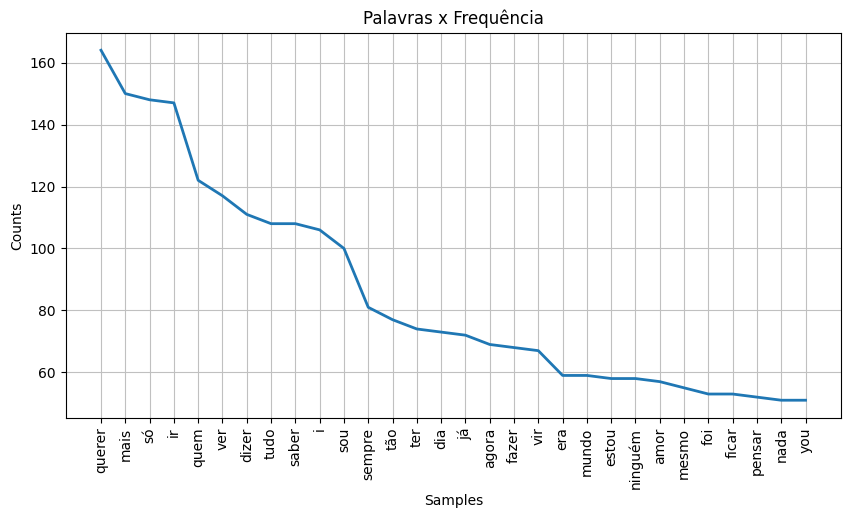

In [ ]:
plt.figure(figsize=(10,5))
fd = nltk.FreqDist(palavras_artista)
fd.plot(30,title = "Palavras x Frequência",cumulative=False)

## Nuvem de palavras (Wordcloud)

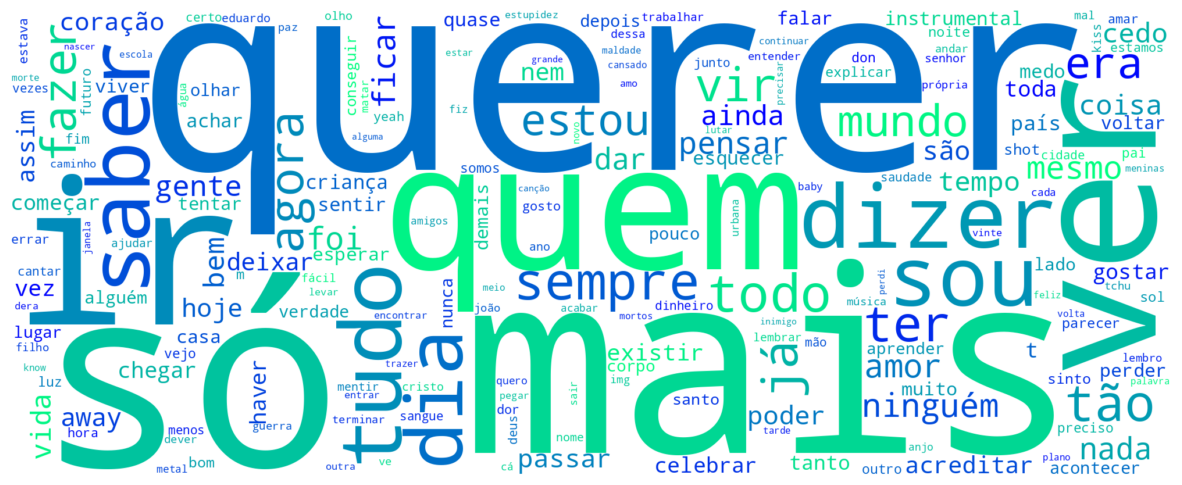

In [ ]:
text = " ".join(palavras_artista)
wordcloud = WordCloud(background_color="white",width=2000, height=800, collocations = False, colormap='winter').generate(text)
fig = plt.figure(figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
fig.savefig('Legiao_Urbana.png', dpi=fig.dpi)
plt.show()

Avaliando a frequência de palavras por álbum da banda.

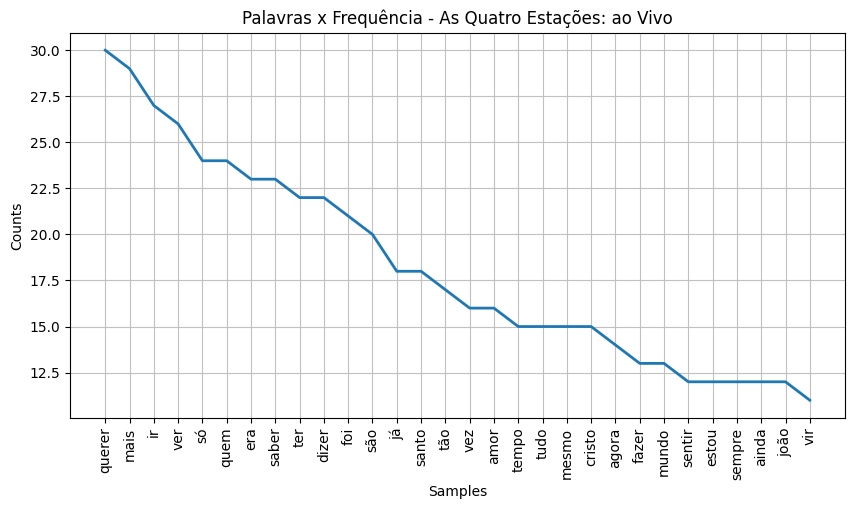

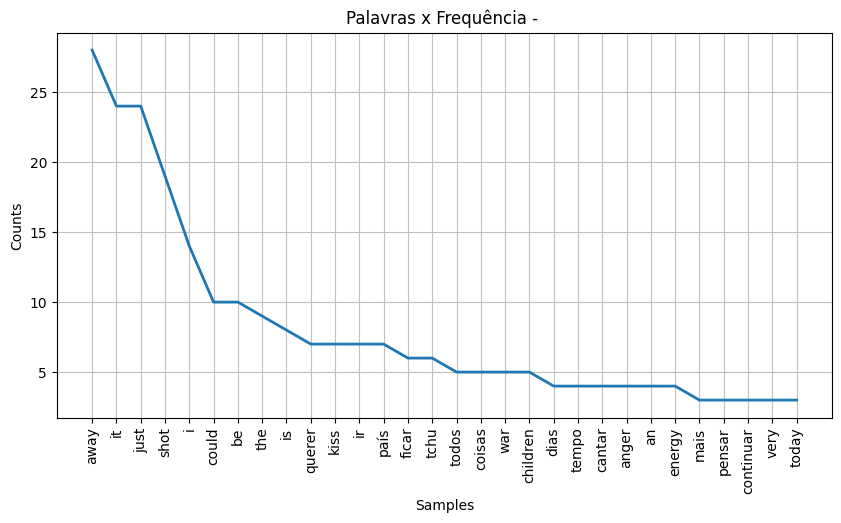

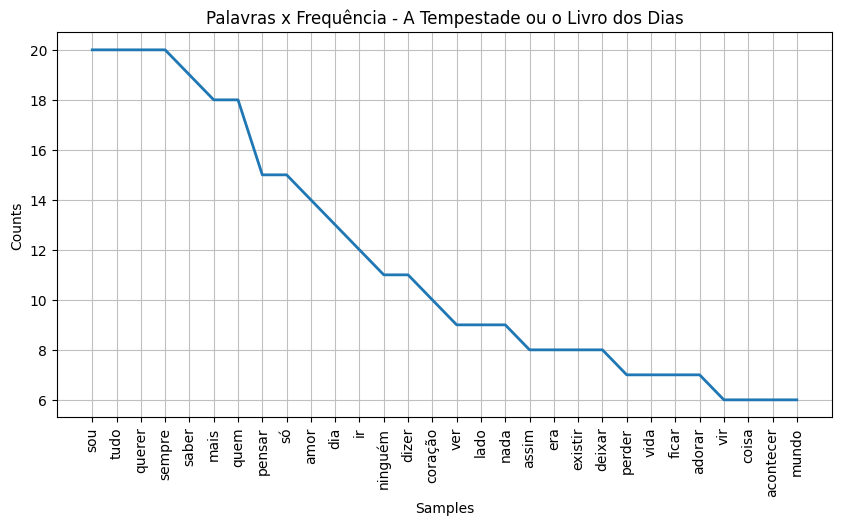

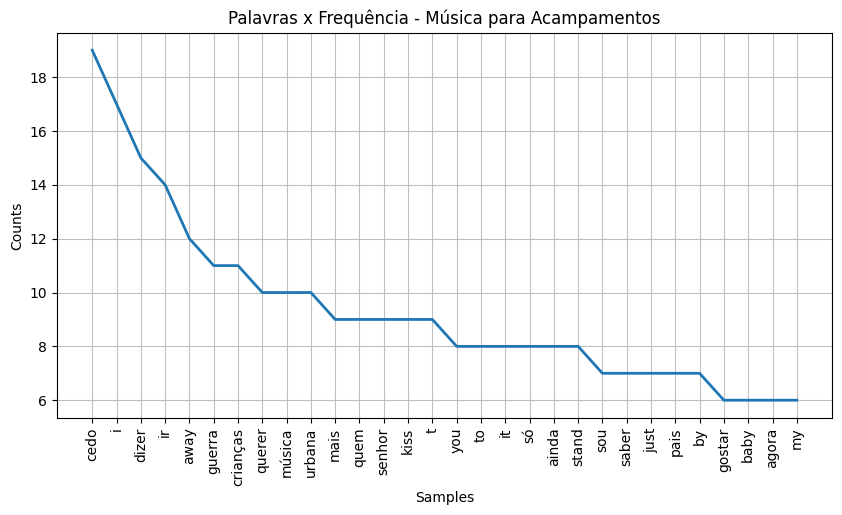

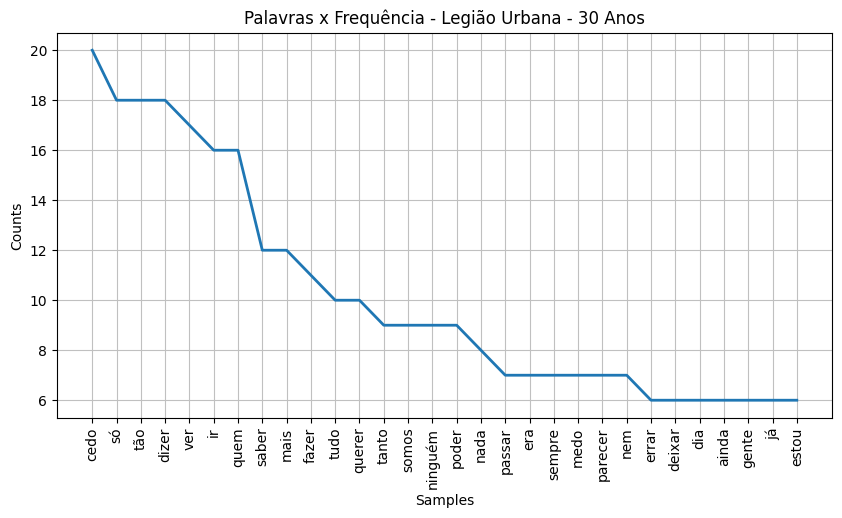

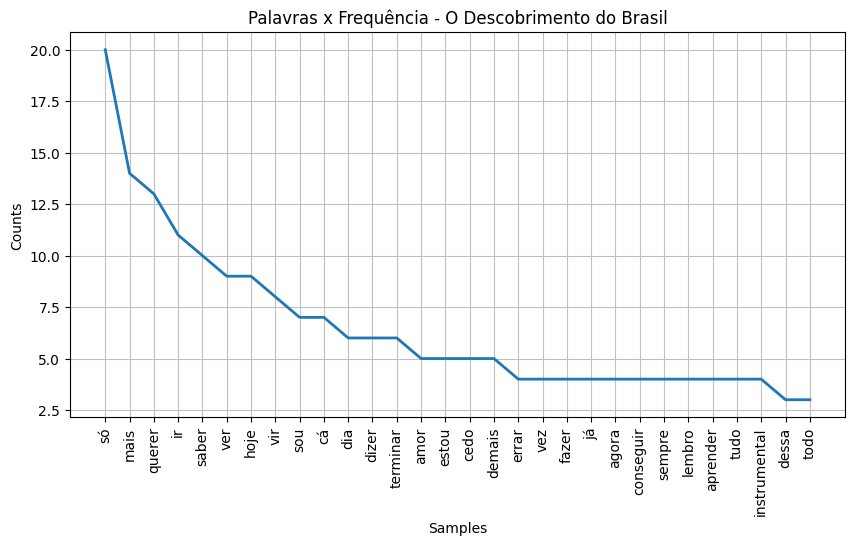

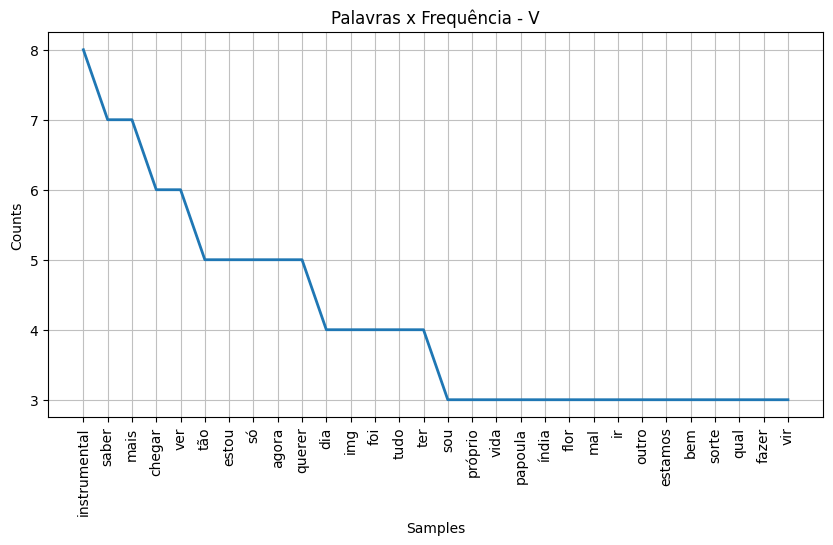

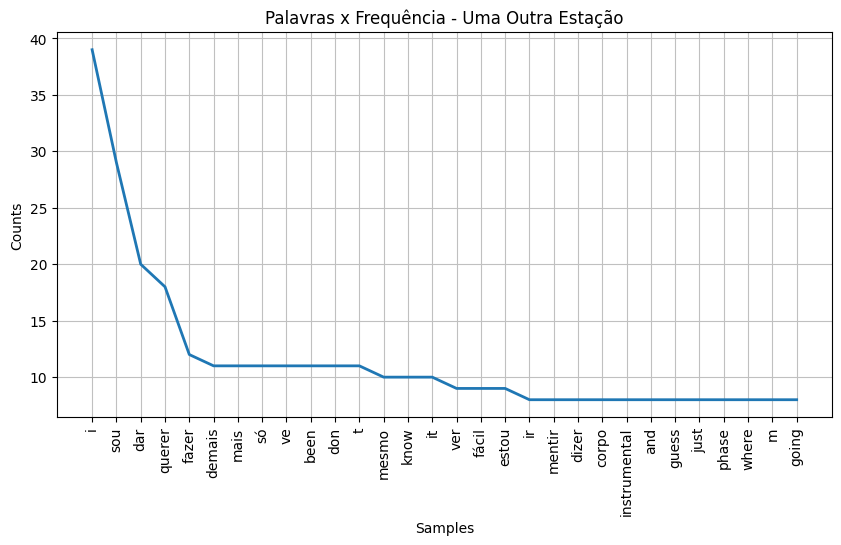

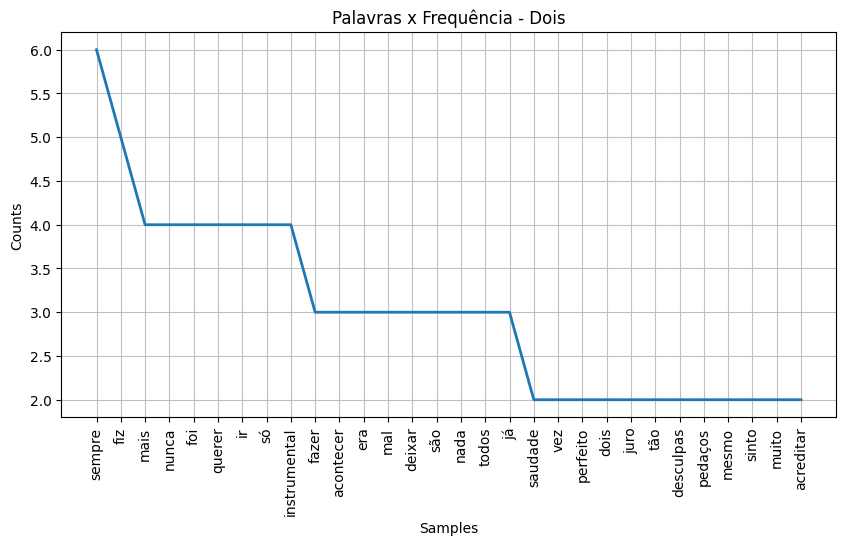

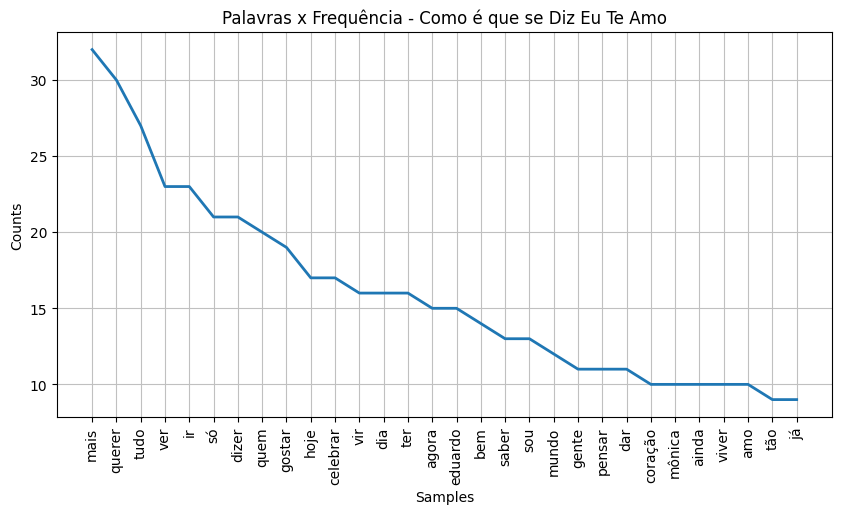

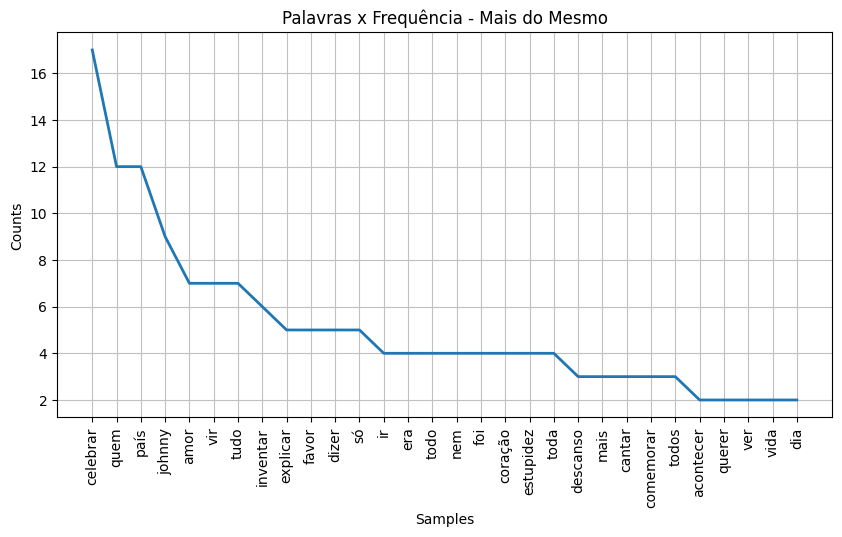

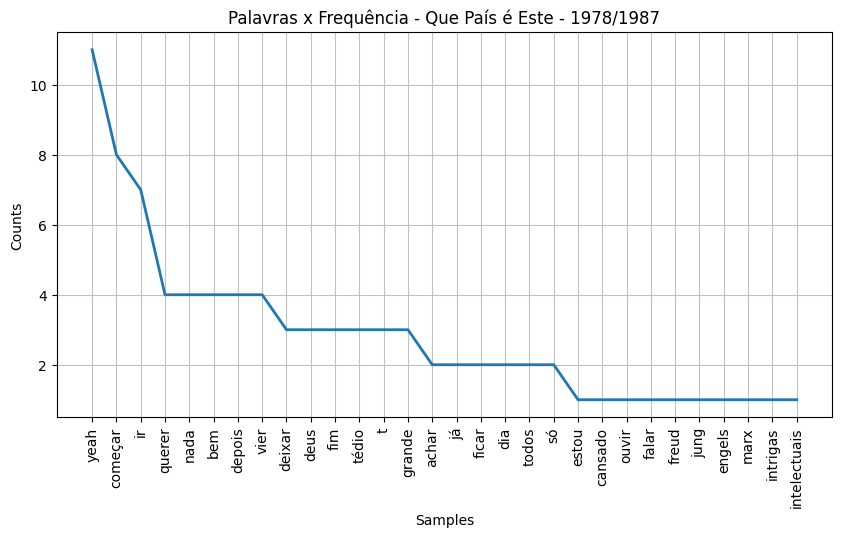

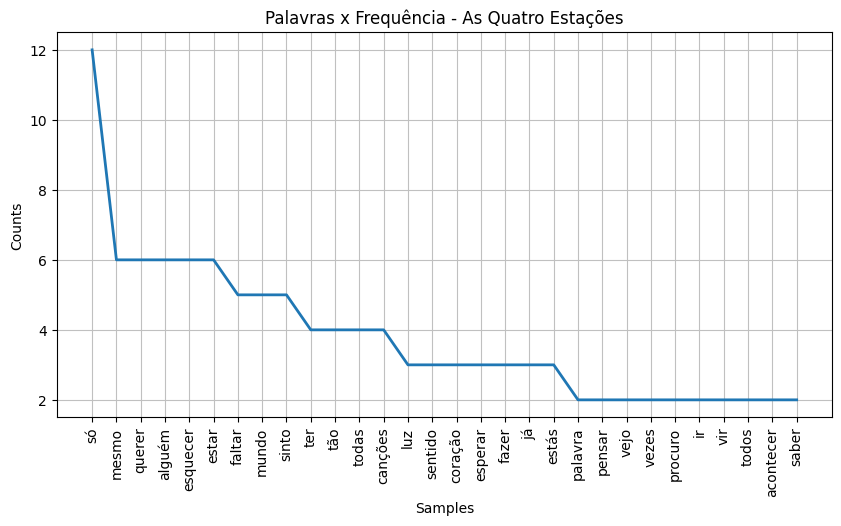

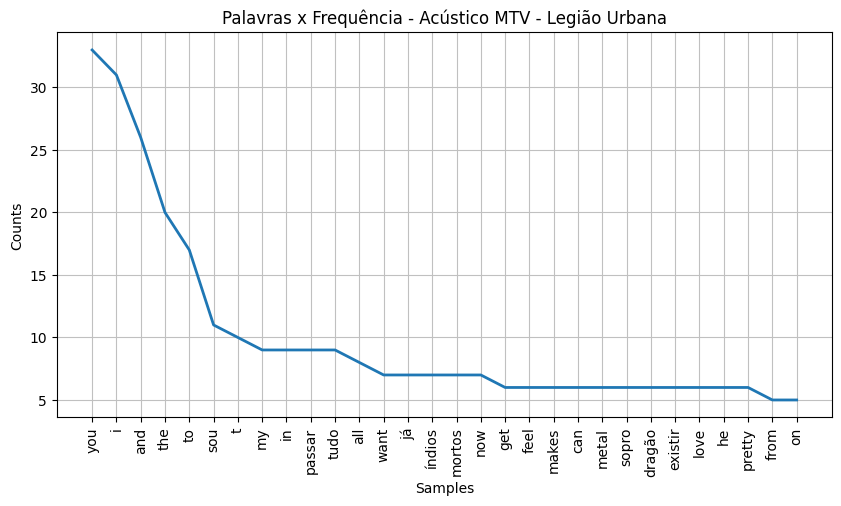

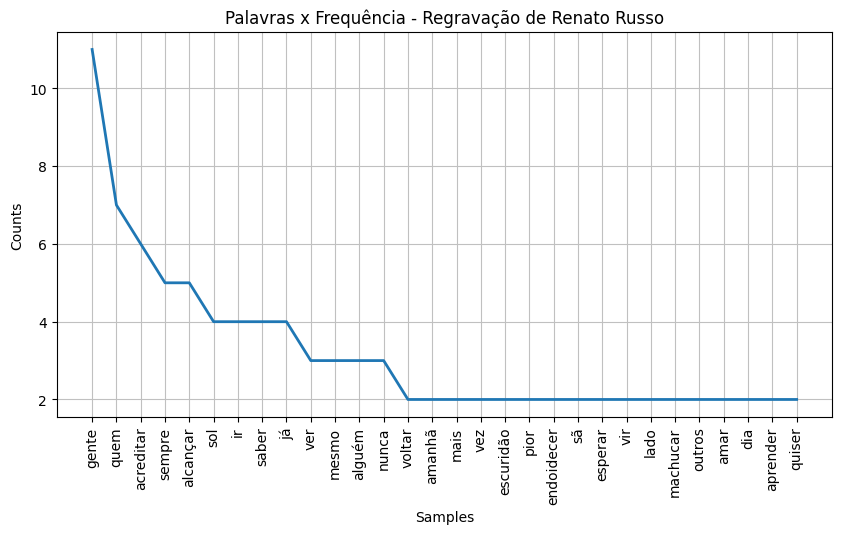

In [ ]:
albuns = musicas['album'].unique()
def frequency_plot(album):
    musicas_do_album = musicas[musicas['album'] == album]['letra']
    letras_combinadas = ' '.join(musicas_do_album).lower()
    palavras_album = limpar_texto(letras_combinadas)
    plt.figure(figsize=(10,5))
    fd = nltk.FreqDist(palavras_album)
    titulo = "Palavras x Frequência - " +  album
    fd.plot(30, title = titulo, cumulative=False)

for album in albuns:
    frequency_plot(album)
plt.show()

## Concordância e Similaridade

Vamos avaliar as palavras no contexto que aparecem, e vamos fazer essa análise dentro da obra da Legião Urbana.

Como no artigo, vamos utilizar dois métodos da biblioteca `nltk`. O primeiro é o `concordance()`, que nos retornará uma lista de contextos diferentes em que uma dada palavra aparece. Esta visualização de resultados é conhecida como KWIC, "*Key Word In Context*" ("Palavra-chave em Contexto"), exibindo todas as ocorrências da palavra, juntamente com algumas palavras anteriores e posteriores (normalmente 80 palavras ao redor).

O segundo é o `similar()` que nos retorna quais palavras mais aparecem no mesmo contexto que uma dada palavra.

A lógica por trás de `similar()` baseia-se na "Hipótese Distribucional": palavras que aparecem em contextos semelhantes tendem a ter significados ou funções gramaticais semelhantes.


In [ ]:
# Com a palavra 'querer'

musicas_text = nltk.Text(palavras_artista)
musicas_text.concordance('querer')

Displaying 25 of 164 matches:
oder irmão esquecer ter sorte agora querer transformar dignidade doença querer
querer transformar dignidade doença querer transformar inteligência traição qu
er transformar inteligência traição querer transformar estupidez recompensa qu
er transformar estupidez recompensa querer transformar esperança maldição bem 
 brasil país toda qualquer situação querer tudo cima cima cima todos dias acor
 chegar algum lugar só depois dizer querer ficar coincidência indiferença falt
os dias tento esquecer todas coisas querer mais só inconsequência tempo contin
rencial quase sempre foi proposital querer ficar cidade começar brincar eletri
cidade começar brincar eletricidade querer ficar nessa idade vejo aprender qua
lher sou mãe filha irmã ser só quem querer sou deus deusar amor alguma coisa a
lher sou mãe filha irmã ser só quem querer sou deus deusar amor baby baby baby
sou cópia faço temos restar estamos querer demais papoula índia flor tailânder
udar vida deixar copo 

In [ ]:
# Com a palavra 'só'

musicas_text.concordance('só')

Displaying 25 of 148 matches:
 todos dias tentar chegar algum lugar só depois dizer querer ficar coincidênci
nto esquecer todas coisas querer mais só inconsequência tempo continuar oscila
njo sou mulher sou mãe filha irmã ser só quem querer sou deus deusar amor algu
njo sou mulher sou mãe filha irmã ser só quem querer sou deus deusar amor baby
 guerra gostar crianças saber direito só vejo preconceito roupa nova só roupa 
ireito só vejo preconceito roupa nova só roupa nova idéias acompanhar moda tra
atar meninas fossem lixo espécie rara só pertencer espécie rara respeita espéc
er espécie rara respeita espécie rara só objeto usar jogar depois prazer tão m
 moderno achar tão moderno igual pais só questão idade passar dessa fase tanto
cuidado dia dançar somos tão modernos só somos sinceros escondemos mais mais s
ó somos sinceros escondemos mais mais só questão idade passar dessa fase tanto
és fazes tão mal ficar tinha ir estou só pouco cansado saber terminar joelho d
ismo amizade matemátic

Vamos ver quais palavras mais aparecem no mesmo contexto que essas. Vamos usar o método `similar()` para isso.

In [ ]:
# Similar para a palavra 'querer'

musicas_text.similar('querer')

foi ir ter tempo futuro vejo valer existir mesmo vez yeah convencer
amarar


In [ ]:
# Similar para a palavra 'só'

musicas_text.similar('só')

mal tudo brincar ninguém canção vezes difícil amar realmente pesar
documentação errado
